<a href="https://colab.research.google.com/github/LucianoMacias/Aplicacion_Nuevas_Tecnologias-Luciano_Macias/blob/main/tp04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


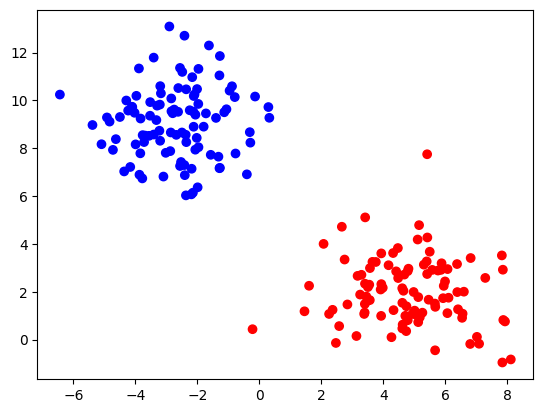

In [9]:
X, y = make_blobs(
    n_samples=200,
    centers=2,
    n_features=2,
    cluster_std=1.5,
    random_state=42
)

plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr")
plt.show()

In [13]:
class Perceptron:

    def __init__(self, n_features, learning_rate=0.01):

        self.lr = learning_rate

        self.weights = np.random.randn(n_features)

        self.bias = np.random.randn()

        self.errors = []

    def activation(self, x):

        if x >= 0:
            return 1

        return 0

    def predict(self, X):

        z = np.dot(X, self.weights) + self.bias

        return self.activation(z)

    def train(self, X, y, epochs=100):

        for epoch in range(epochs):

            total_errors = 0

            for xi, target in zip(X, y):

                prediction = self.predict(xi)

                error = target - prediction

                self.weights += self.lr * error * xi

                self.bias += self.lr * error

                total_errors += abs(error)

            self.errors.append(total_errors)

In [16]:
def plot_decision_boundary(model, X, y, title):

    plt.figure(figsize=(8,6))

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y,
        cmap="bwr"
    )

    x_values = np.array([
        X[:,0].min(),
        X[:,0].max()
    ])

    y_values = (
        -(model.weights[0] * x_values + model.bias)
        / model.weights[1]
    )

    plt.plot(
        x_values,
        y_values,
        color="black"
    )

    plt.title(title)

    plt.show()

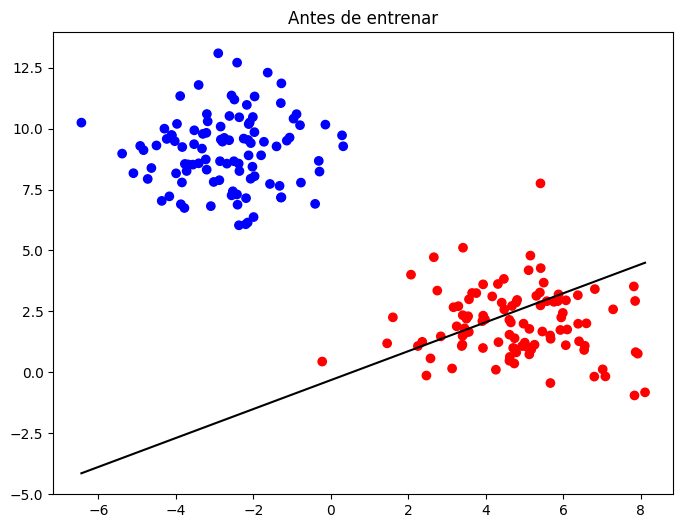

In [17]:
p = Perceptron(2)

plot_decision_boundary(
    p,
    X,
    y,
    "Antes de entrenar"
)

In [19]:
p.train(
    X,
    y,
    epochs=50
)

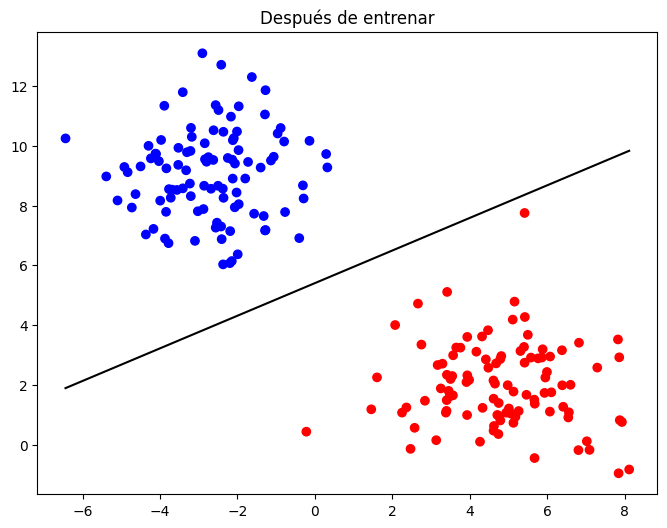

In [20]:
plot_decision_boundary(
    p,
    X,
    y,
    "Después de entrenar"
)

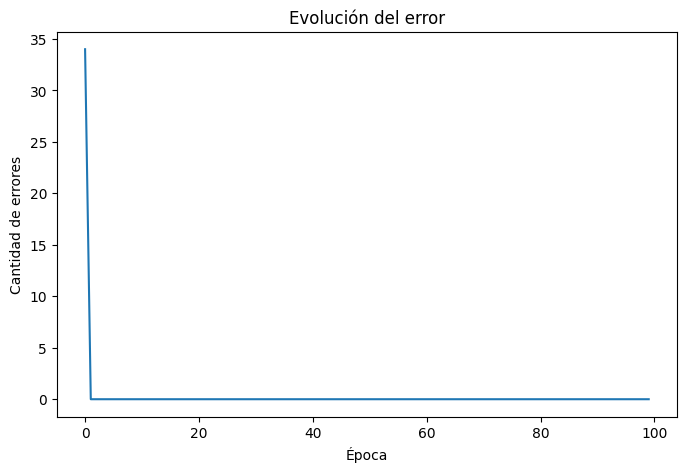

In [21]:
plt.figure(figsize=(8,5))

plt.plot(p.errors)

plt.xlabel("Época")
plt.ylabel("Cantidad de errores")
plt.title("Evolución del error")

plt.show()

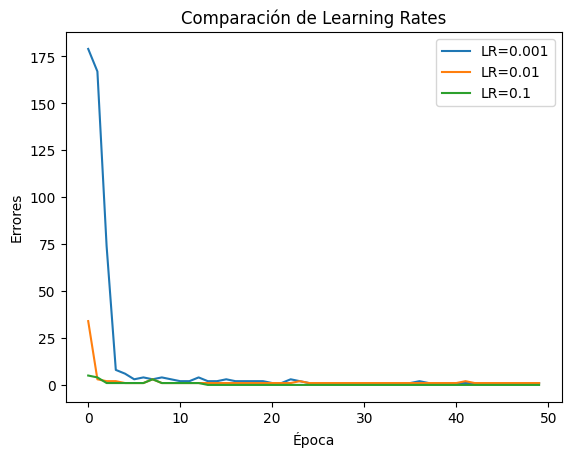

In [22]:
learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:

    perceptron = Perceptron(
        n_features=2,
        learning_rate=lr
    )

    perceptron.train(
        X,
        y,
        epochs=50
    )

    plt.plot(
        perceptron.errors,
        label=f"LR={lr}"
    )

plt.xlabel("Época")
plt.ylabel("Errores")
plt.title("Comparación de Learning Rates")
plt.legend()

plt.show()

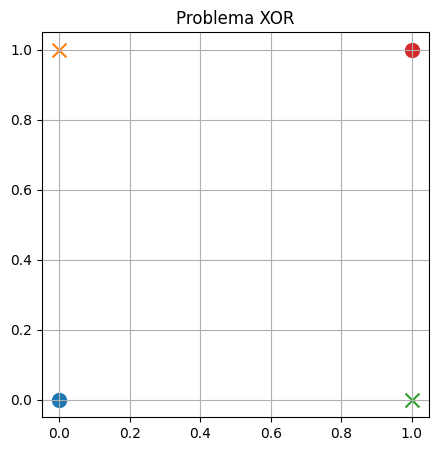

In [23]:
xor_X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

xor_y = np.array([
    0,
    1,
    1,
    0
])

plt.figure(figsize=(5,5))

for point, label in zip(xor_X, xor_y):

    if label == 0:
        plt.scatter(point[0], point[1], marker='o', s=100)

    else:
        plt.scatter(point[0], point[1], marker='x', s=100)

plt.grid()
plt.title("Problema XOR")
plt.show()

# Trabajo Práctico: Implementación de un Perceptrón desde Cero

## Introducción

El objetivo de este trabajo es implementar un perceptrón utilizando únicamente NumPy y Matplotlib, sin emplear librerías de Machine Learning para el entrenamiento del modelo. El perceptrón es uno de los algoritmos más simples de aprendizaje supervisado y constituye la base histórica de las redes neuronales artificiales.

En este trabajo se generó un conjunto de datos bidimensional con dos clases utilizando `make_blobs`. Posteriormente se implementó una clase `Perceptron` capaz de realizar predicciones y actualizar sus pesos mediante la regla de aprendizaje del perceptrón. Finalmente se analizó su comportamiento sobre datos linealmente separables y se estudiaron algunas de sus limitaciones.

---

## Generación del Dataset

Se generó un conjunto de datos bidimensional compuesto por dos clases claramente diferenciadas. La distribución de los puntos permite que exista una frontera de decisión lineal capaz de separarlos correctamente, lo que resulta adecuado para evaluar el comportamiento del perceptrón.

---

## Implementación del Perceptrón

La implementación incluye los siguientes componentes:

* Inicialización aleatoria de pesos y bias.
* Función de activación escalón (step function).
* Método de predicción basado en la combinación lineal de entradas y pesos.
* Algoritmo de entrenamiento utilizando la regla de actualización del perceptrón.

La actualización de los pesos se realiza mediante:

w = w + η · error · x

donde:

* w representa los pesos.
* η es el learning rate.
* error es la diferencia entre la etiqueta real y la predicción.
* x representa las características de entrada.

---

## Frontera de Decisión

Antes del entrenamiento, la frontera de decisión fue generada a partir de pesos aleatorios y no representaba adecuadamente la separación entre las clases.

Después del entrenamiento, el perceptrón ajustó sus pesos y logró encontrar una recta capaz de separar correctamente ambos grupos de datos.

---

## Evolución del Error

La gráfica de error por época mostró una reducción muy rápida de la cantidad de errores de clasificación.

Durante la primera época se registraron aproximadamente 34 errores. A partir de la segunda época el error se redujo a cero y permaneció en ese valor durante el resto del entrenamiento.

Esto indica que el perceptrón logró converger correctamente para este conjunto de datos.

---

# Análisis y Respuestas

## ¿Por qué el perceptrón no puede resolver XOR?

El problema XOR no es linealmente separable. Esto significa que no existe una única línea recta que permita dividir correctamente las dos clases.

En XOR, los puntos pertenecientes a una misma clase se encuentran ubicados en esquinas opuestas del espacio de características. Como el perceptrón simple únicamente puede aprender fronteras de decisión lineales, no puede clasificar correctamente todos los ejemplos del problema.

Para resolver XOR es necesario utilizar modelos más complejos, como redes neuronales multicapa que incorporen capas ocultas y funciones de activación no lineales.

---

## ¿Qué pasa si cambian el learning rate?

El learning rate controla el tamaño de los ajustes realizados sobre los pesos durante el entrenamiento.

* Con un learning rate pequeño (0.001), el aprendizaje es más lento porque los pesos se modifican en pasos pequeños.
* Con un learning rate intermedio (0.01), se obtiene un equilibrio adecuado entre velocidad y estabilidad.
* Con un learning rate mayor (0.1), el modelo converge más rápidamente, aunque valores excesivamente grandes podrían provocar oscilaciones e inestabilidad.

En este conjunto de datos, todos los learning rates probados permitieron la convergencia debido a que las clases estaban claramente separadas.

---

## ¿Cuántas épocas necesitó para converger? ¿De qué depende?

El perceptrón convergió aproximadamente en 2 épocas. Esto puede observarse en la gráfica de evolución del error, donde la cantidad de errores cae a cero después de la primera época y permanece en cero durante el resto del entrenamiento.

La velocidad de convergencia depende de varios factores:

* La separación entre las clases.
* La calidad de la inicialización de los pesos.
* El valor del learning rate.
* La complejidad del problema.

Cuando los datos son linealmente separables, el perceptrón suele converger rápidamente. En cambio, si las clases no pueden separarse mediante una recta, el algoritmo puede no converger nunca.

---

## Experimento con Datos No Linealmente Separables

Se generó un segundo conjunto de datos con una mayor dispersión entre las clases. En este caso, las regiones de ambas clases se superponen y no existe una frontera lineal capaz de separarlas perfectamente.

Como consecuencia, el perceptrón no puede alcanzar una clasificación perfecta y la cantidad de errores no llega necesariamente a cero. Esto demuestra una de las principales limitaciones del perceptrón simple: únicamente puede resolver problemas linealmente separables.

---

## Conclusión

El perceptrón es un modelo sencillo pero fundamental para comprender el funcionamiento de las redes neuronales. En este trabajo se observó que puede aprender correctamente cuando los datos son linealmente separables y que converge rápidamente bajo estas condiciones.

Sin embargo, también se comprobó que presenta limitaciones importantes frente a problemas más complejos, como XOR o conjuntos de datos no linealmente separables. Estas limitaciones motivaron el desarrollo de arquitecturas más avanzadas, como las redes neuronales multicapa utilizadas actualmente en Machine Learning y Deep Learning.
